<div style="text-align:center; padding:20px 0">
<img src="https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/media/logo_dataprojectlab.png" width="220"/>
</div>

# TelcomCI — RH & Masse Salariale
## Notebook 2 — SQL Analytics : Masse Salariale, Turnover & Performance
### ✅ VERSION CORRIGÉE

> **Comment lire ce corrigé :**  
> Les blocs `MÉTHODE` expliquent les choix techniques et les patterns généralisables.  
> Les blocs `INTERPRÉTATION` lisent les résultats.  
> Les blocs `MÉTIER` font le lien entre le chiffre et la décision business.

| | |
|---|---|
| **Prérequis** | Notebook 1 complété |
| **Niveau** | Avancé |
| **Outils** | Python, DuckDB (JupySQL), pandas |
| **Durée estimée** | 4h à 5h |

> **5 questions business** auxquelles ce notebook répond :
> 1. Quelle est l'**évolution de la masse salariale** mois par mois par département ?
> 2. Quels départements ont le **turnover le plus élevé** et quels en sont les motifs ?
> 3. Quels employés sont **les plus performants et sous-payés** par rapport à leur poste ?
> 4. Quel est le **coût réel du recrutement** par canal ?
> 5. **L'absentéisme a-t-il augmenté** en 2023 vs 2022 ?

---
## 0. Mise en place de l'environnement

In [33]:
!pip install jupysql==0.11.1 duckdb-engine --quiet


[notice] A new release of pip is available: 24.1 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import os, sys, warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

COLORS = {
    'primary':   '#534AB7',
    'secondary': '#1D9E75',
    'warning':   '#EF9F27',
    'danger':    '#E24B4A',
    'neutral':   '#888780',
}
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F9F9F8',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        11,
})

# ── Détection Colab / Local ──────────────────────────────────────────────────
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_PATH = '/content/drive/MyDrive/DataProjectLab/projects/rh_analytics/'
else:
    SAVE_PATH = './outputs/'
os.makedirs(SAVE_PATH, exist_ok=True)
print(f'📁 Environnement : {"Colab" if IN_COLAB else "Local"}')
print(f'📁 Dossier       : {SAVE_PATH}')
print('Configuration chargée ✅')

📁 Environnement : Local
📁 Dossier       : ./outputs/
Configuration chargée ✅


In [35]:
BASE_URL = 'https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/projets/rh_analytics/data/'

# On recharge les tables depuis zéro — état propre et reproductible
conn = duckdb.connect()
conn.execute(f"""
    CREATE TABLE departements  AS SELECT * FROM read_csv_auto('{BASE_URL}departements.csv');
    CREATE TABLE employes      AS SELECT * FROM read_csv_auto('{BASE_URL}employes.csv',     timestampformat='%Y-%m-%d');
    CREATE TABLE salaires      AS SELECT * FROM read_csv_auto('{BASE_URL}salaires.csv');
    CREATE TABLE absences      AS SELECT * FROM read_csv_auto('{BASE_URL}absences.csv',     timestampformat='%Y-%m-%d');
    CREATE TABLE recrutements  AS SELECT * FROM read_csv_auto('{BASE_URL}recrutements.csv', timestampformat='%Y-%m-%d');
    CREATE TABLE evaluations   AS SELECT * FROM read_csv_auto('{BASE_URL}evaluations.csv');
""")
print('✅ 6 tables chargées')

%load_ext sql
%sql conn --alias duckdb
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
print('%%sql prêt ✅')

✅ 6 tables chargées
The sql extension is already loaded. To reload it, use:
  %reload_ext sql
%%sql prêt ✅


---
## Étape 1 — Vues de nettoyage

### MÉTHODE — Principe de conservation des données brutes

On ne modifie jamais les tables sources. On crée des **vues** qui filtrent les anomalies détectées en NB1. Si on découvre une erreur dans la logique de filtrage, on corrige la vue sans toucher aux données originales.

> **DuckDB :** `CREATE OR REPLACE VIEW` remplace `CREATE OR ALTER VIEW` de SQL Server — syntaxe identique, même comportement.
>
> **Power BI se connectera aux vues**, pas aux tables brutes. Cela garantit que le dashboard reflète toujours des données propres.

In [36]:
%%sql
-- VUE 1 : employés propres (sans salaires aberrants ni doublons email)
CREATE OR REPLACE VIEW vw_employes_propres AS
SELECT *
FROM employes
WHERE salaire_base > 0
  AND employe_id IN (
      SELECT MIN(employe_id)
      FROM employes
      WHERE email IS NOT NULL
      GROUP BY email
  );

,Count


In [37]:
%%sql
-- VUE 2 : salaires valides (nets positifs et payés)
CREATE OR REPLACE VIEW vw_salaires_valides AS
SELECT *
FROM salaires
WHERE salaire_net     > 0
  AND statut_paiement = 'Paye';

,Count


In [38]:
%%sql
-- VUE 3 : absences valides (nb_jours positifs)
CREATE OR REPLACE VIEW vw_absences_valides AS
SELECT *
FROM absences
WHERE nb_jours > 0;

,Count


In [39]:
%%sql 
SELECT 'employes brut'         AS source, COUNT(*) AS nb FROM employes           UNION ALL
SELECT 'vw_employes_propres',   COUNT(*) FROM vw_employes_propres                 UNION ALL
SELECT 'salaires brut',         COUNT(*) FROM salaires                            UNION ALL
SELECT 'vw_salaires_valides',   COUNT(*) FROM vw_salaires_valides                 UNION ALL
SELECT 'absences brut',         COUNT(*) FROM absences                            UNION ALL
SELECT 'vw_absences_valides',   COUNT(*) FROM vw_absences_valides

,source,nb
0,employes brut,510
1,vw_employes_propres,506
2,salaires brut,17319
3,vw_salaires_valides,17137
4,absences brut,622
5,vw_absences_valides,619


> **INTERPRÉTATION :**
>
> | Vue | Lignes brutes | Lignes propres | Retirées |
> |---|---|---|---|
> | vw_employes_propres | 510 | **506** | 4 (2 sal. aberrants + 2 doublons email) |
> | vw_salaires_valides | 17 319 | **17 137** | 182 (3 nets négatifs + 179 'En attente') |
> | vw_absences_valides | 622 | **619** | 3 (nb_jours négatifs) |

---
## Étape 2 — Masse salariale mensuelle avec LAG()

### MÉTHODE — LAG() : la fenêtre temporelle

`LAG(colonne, 1) OVER (PARTITION BY dept ORDER BY periode)` retourne la valeur de la ligne précédente dans la partition. En RH, c'est l'outil fondamental pour calculer 'combien la masse salariale a-t-elle changé ce mois vs le mois dernier ?'

**Pourquoi une CTE ?** La CTE `ms_mensuelle` pré-calcule la masse salariale par département/mois. La requête principale applique ensuite `LAG()` sur ce résultat. Sans CTE, on serait obligé d'imbriquer une sous-requête dans une autre — illisible.

In [40]:
%%sql  
WITH ms_mensuelle AS (
    SELECT
        s.departement_id,
        d.nom                                    AS departement,
        s.annee,
        s.mois,
        s.periode,
        SUM(s.salaire_brut + s.prime)            AS masse_salariale,
        COUNT(DISTINCT s.employe_id)             AS nb_employes
    FROM vw_salaires_valides s
    JOIN departements d ON s.departement_id = d.departement_id
    GROUP BY s.departement_id, d.nom, s.annee, s.mois, s.periode
)
select * from ms_mensuelle

,departement_id,departement,annee,mois,periode,masse_salariale,nb_employes
0,DEP01,Direction Generale,2021,7,2021-07,10407350.00,4
1,DEP01,Direction Generale,2021,8,2021-08,10407350.00,4
2,DEP01,Direction Generale,2022,1,2022-01,11040999.00,4
3,DEP01,Direction Generale,2022,3,2022-03,11040999.00,4
4,DEP01,Direction Generale,2022,5,2022-05,11040999.00,4
...,...,...,...,...,...,...,...
415,DEP10,Logistique & Achats,2022,6,2022-06,23150704.00,21
416,DEP10,Logistique & Achats,2022,7,2022-07,18117335.00,20
417,DEP10,Logistique & Achats,2023,4,2023-04,19668356.00,21
418,DEP10,Logistique & Achats,2023,10,2023-10,20273356.00,22


In [41]:
%%sql  
WITH ms_mensuelle AS (
    SELECT
        s.departement_id,
        d.nom                                    AS departement,
        s.annee,
        s.mois,
        s.periode,
        SUM(s.salaire_brut + s.prime)            AS masse_salariale,
        COUNT(DISTINCT s.employe_id)             AS nb_employes
    FROM vw_salaires_valides s
    JOIN departements d ON s.departement_id = d.departement_id
    GROUP BY s.departement_id, d.nom, s.annee, s.mois, s.periode
)
SELECT
    departement_id,                             
    departement,
    annee, mois, periode,
    masse_salariale,
    nb_employes,
    LAG(masse_salariale) OVER (
        PARTITION BY departement
        ORDER BY periode
    )                                            AS ms_mois_prec,
    ROUND(
        (masse_salariale
         - LAG(masse_salariale) OVER (PARTITION BY departement ORDER BY periode))
        * 100.0
        / NULLIF(LAG(masse_salariale) OVER (PARTITION BY departement ORDER BY periode), 0)
    , 1)                                         AS variation_pct,
    RANK() OVER (
        PARTITION BY annee, mois
        ORDER BY masse_salariale DESC
    )                                            AS rang_mensuel
FROM ms_mensuelle
ORDER BY departement, periode

,departement_id,departement,annee,mois,periode,masse_salariale,nb_employes,ms_mois_prec,variation_pct,rang_mensuel
0,DEP02,Commercial & Ventes,2021,1,2021-01,54811127.00,63,NaN,NaN,3
1,DEP02,Commercial & Ventes,2021,2,2021-02,55961127.00,64,54811127.00,2.10,3
2,DEP02,Commercial & Ventes,2021,3,2021-03,54828848.00,63,55961127.00,-2.00,3
3,DEP02,Commercial & Ventes,2021,4,2021-04,57739127.00,65,54828848.00,5.30,3
4,DEP02,Commercial & Ventes,2021,5,2021-05,54835441.00,63,57739127.00,-5.00,3
...,...,...,...,...,...,...,...,...,...,...
415,DEP03,Technique & Reseau,2024,2,2024-02,106258539.00,98,107097971.00,-0.80,1
416,DEP03,Technique & Reseau,2024,3,2024-03,105276025.00,97,106258539.00,-0.90,1
417,DEP03,Technique & Reseau,2024,4,2024-04,102597859.00,96,105276025.00,-2.50,1
418,DEP03,Technique & Reseau,2024,5,2024-05,104667610.00,97,102597859.00,2.00,1


In [42]:
%%sql 
-- Synthèse : masse salariale totale par année et par département
WITH ms_annuelle AS (
    SELECT
        d.nom                               AS departement,
        s.annee,
        ROUND(SUM(s.salaire_brut), 0)       AS masse_brute,
        ROUND(SUM(s.prime), 0)              AS total_primes,
        ROUND(SUM(s.salaire_brut + s.prime), 0) AS masse_totale,
        COUNT(DISTINCT s.employe_id)        AS nb_employes_moy
    FROM vw_salaires_valides s
    JOIN departements d ON s.departement_id = d.departement_id
    GROUP BY d.departement_id, d.nom, s.annee
)
SELECT
    departement,
    annee,
    masse_totale,
    nb_employes_moy,
    ROUND(masse_totale * 100.0
          / SUM(masse_totale) OVER (PARTITION BY annee), 1) AS pct_annee,
    RANK() OVER (PARTITION BY annee ORDER BY masse_totale DESC) AS rang
FROM ms_annuelle
ORDER BY annee, rang

,departement,annee,masse_totale,nb_employes_moy,pct_annee,rang
0,Technique & Reseau,2021,996698792.00,90,23.30,1
1,Service Client,2021,883337647.00,106,20.60,2
2,Commercial & Ventes,2021,765053902.00,70,17.90,3
3,Informatique & Systemes,2021,462448388.00,30,10.80,4
4,Marketing & Communication,2021,300043808.00,24,7.00,5
5,Finance & Comptabilite,2021,238130255.00,25,5.60,6
6,Logistique & Achats,2021,226218629.00,22,5.30,7
7,Juridique & Conformite,2021,163034408.00,10,3.80,8
8,Ressources Humaines,2021,138712152.00,12,3.20,9
9,Direction Generale,2021,107143811.00,4,2.50,10


> **INTERPRÉTATION — Évolution de la masse salariale :**
>
> | Année | Masse totale | Évolution |
> |---|---|---|
> | 2021 | 4.28 Mrd FCFA | Référence |
> | 2022 | 5.00 Mrd FCFA | **+16.8%** |
> | 2023 | 5.75 Mrd FCFA | **+15.0%** |
> | 2024 (6 mois) | 2.89 Mrd FCFA | Rythme annuel ~5.77 Mrd |
>
> **Top 3 départements :** Technique & Réseau (23.1%), Service Client (19.6%), Commercial & Ventes (17.7%).
>
> **Saisonnalité :** les variations de +100% en décembre s'expliquent par les primes de fin d'année. Les baisses de -47 à -50% en janvier reflètent l'absence de primes.

---
## Étape 3 — Taux de turnover avec CTEs et RANK()

### MÉTHODE — Calcul du taux de turnover

**Formule :** `Taux = Nb départs sur l'année / Effectif total du département × 100`

On utilise le dénominateur 'effectif total' (actifs + inactifs) qui inclut les départs eux-mêmes — méthode la plus conservative. **Architecture de la requête — 2 CTEs :**
- `departs_annee` : compte les départs par département, année et motif
- `effectif_total` : calcule l'effectif de référence par département

> **DuckDB :** `YEAR(date_depart)` fonctionne identiquement à SQL Server.

In [55]:
%%sql 
WITH departs_annee AS (
    SELECT
        departement_id,
        YEAR(date_depart)          AS annee,
        COUNT(*)                   AS nb_departs
    FROM vw_employes_propres
    WHERE date_depart IS NOT NULL
      AND YEAR(date_depart) IN (2021, 2022, 2023)
    GROUP BY departement_id, YEAR(date_depart)
),
effectif_total AS (
    SELECT
        departement_id,
        COUNT(*)                   AS effectif
    FROM employes
    GROUP BY departement_id
)
SELECT
    d.nom                                           AS departement,
    da.annee,
    da.nb_departs,
    et.effectif                                     AS effectif_total,
    ROUND(da.nb_departs * 100.0
          / NULLIF(et.effectif, 0), 1)              AS taux_turnover_pct,
    RANK() OVER (
        PARTITION BY da.annee
        ORDER BY da.nb_departs * 100.0
                 / NULLIF(et.effectif, 0) DESC
    )                                               AS rang_risque
FROM departs_annee da
JOIN effectif_total et ON da.departement_id = et.departement_id
JOIN departements d    ON da.departement_id = d.departement_id
ORDER BY da.annee, rang_risque

,departement,annee,nb_departs,effectif_total,taux_turnover_pct,rang_risque
0,Logistique & Achats,2021,2,25,8.00,1
1,Commercial & Ventes,2021,3,95,3.20,2
2,Informatique & Systemes,2021,1,45,2.20,3
3,Service Client,2021,2,130,1.50,4
4,Logistique & Achats,2022,1,25,4.00,1
5,Service Client,2022,5,130,3.80,2
6,Marketing & Communication,2022,1,30,3.30,3
7,Technique & Reseau,2022,3,110,2.70,4
8,Informatique & Systemes,2022,1,45,2.20,5
9,Commercial & Ventes,2022,1,95,1.10,6


> **INTERPRÉTATION — Turnover par département :**
>
> | Département | 2021 | 2022 | 2023 | Tendance |
> |---|---|---|---|---|
> | Finance & Comptabilité | — | — | **8.6%** | Hausse 2023 |
> | Marketing & Communication | — | 3.3% | **6.7%** | En hausse |
> | Informatique & Systèmes | 2.2% | 2.2% | **4.4%** | Doublement 2023 |
>
> **Signal fort 2023 :** Finance (+8.6%) et Marketing (+6.7%) ont des taux en forte hausse. La Finance a perdu 3 employés sur 35 en une seule année.

In [56]:
%%sql 
-- Analyse des motifs de départ par département
SELECT
    d.nom                                               AS departement,
    e.motif_depart,
    COUNT(*)                                            AS nb,
    ROUND(COUNT(*) * 100.0
          / SUM(COUNT(*)) OVER (PARTITION BY d.nom), 1) AS pct_du_dept
FROM vw_employes_propres e
JOIN departements d ON e.departement_id = d.departement_id
WHERE e.date_depart IS NOT NULL
GROUP BY d.nom, e.motif_depart
ORDER BY d.nom, nb DESC

,departement,motif_depart,nb,pct_du_dept
0,Commercial & Ventes,Retraite,3,25.00
1,Commercial & Ventes,Fin CDD,3,25.00
2,Commercial & Ventes,Demission,2,16.70
3,Commercial & Ventes,Licenciement,2,16.70
4,Commercial & Ventes,Mutation,2,16.70
5,Finance & Comptabilite,Mutation,2,50.00
6,Finance & Comptabilite,Licenciement,1,25.00
7,Finance & Comptabilite,Fin CDD,1,25.00
8,Informatique & Systemes,Fin CDD,1,25.00
9,Informatique & Systemes,Retraite,1,25.00


> **INTERPRÉTATION — Motifs de départ :**
> - **Marketing** : la Retraite est le motif N°1 (3 sur 7) — profils seniors qui partent sans être remplacés, ce qui explique le sous-effectif chronique (-7 vs cible)
> - **Technique & Réseau** : les Mutations internes sont le motif dominant (4 sur 13) — les profils techniques sont les plus mobiles en interne
> - **Finance** : mix Mutation/Fin CDD/Licenciement — signale une instabilité contractuelle

In [57]:
%%sql 
-- Coût estimé du turnover par département
-- Hypothèse standard : 6 mois de salaire net moyen par départ
WITH sal_net_moy AS (
    SELECT
        departement_id,
        ROUND(AVG(salaire_net), 0) AS salaire_net_moyen
    FROM vw_salaires_valides
    GROUP BY departement_id
),
departs_totaux AS (
    SELECT
        departement_id,
        COUNT(*)                   AS total_departs
    FROM employes
    WHERE date_depart IS NOT NULL
    GROUP BY departement_id
)
SELECT
    d.nom                                                    AS departement,
    dt.total_departs,
    snm.salaire_net_moyen,
    ROUND(dt.total_departs * snm.salaire_net_moyen * 6, 0)  AS cout_turnover_estime,
    RANK() OVER (
        ORDER BY dt.total_departs * snm.salaire_net_moyen * 6 DESC
    )                                                        AS rang_cout
FROM departs_totaux dt
JOIN sal_net_moy snm ON dt.departement_id = snm.departement_id
JOIN departements d  ON dt.departement_id = d.departement_id
ORDER BY rang_cout

,departement,total_departs,salaire_net_moyen,cout_turnover_estime,rang_cout
0,Technique & Reseau,13,901409.00,70309902.00,1
1,Commercial & Ventes,12,849894.00,61192368.00,2
2,Service Client,14,649604.00,54566736.00,3
3,Marketing & Communication,7,1015973.00,42670866.00,4
4,Informatique & Systemes,4,1205501.00,28932024.00,5
5,Logistique & Achats,4,839413.00,20145912.00,6
6,Finance & Comptabilite,4,780832.00,18739968.00,7
7,Juridique & Conformite,1,1230586.00,7383516.00,8
8,Ressources Humaines,1,841018.00,5046108.00,9


> **INTERPRÉTATION — Coût du turnover :**
>
> | Département | Départs | Coût estimé |
> |---|---|---|
> | Technique & Réseau | 13 | **70.3 M FCFA** |
> | Commercial & Ventes | 12 | **61.2 M FCFA** |
> | Service Client | 14 | **54.6 M FCFA** |
> | **TOTAL GROUPE** | **60** | **~309 M FCFA** |
>
> **MÉTIER :** 309 M FCFA de coût de turnover estimé sur la période 2021-2024 — l'équivalent de 53% de la masse salariale d'un mois. Investir dans la rétention est économiquement rationnel même avec un budget conséquent.

---
## Étape 4 — Matrice performance × salaire

### MÉTHODE — NTILE(4) et PERCENT_RANK()

**`NTILE(4)`** divise les employés en 4 groupes de taille égale selon leur salaire.
- Quartile 1 = 25% des salaires les plus bas
- Quartile 4 = 25% des salaires les plus élevés

**`PERCENT_RANK()`** calcule le rang relatif entre 0 et 1 :
```sql
PERCENT_RANK() OVER (ORDER BY note_globale DESC)
→ 0.0 = meilleur performeur | 0.1 = top 10% | 1.0 = moins bon
```

> **DuckDB :** `PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY col)` est supporté nativement — identique à SQL Server.

In [58]:
%%sql 
-- Requête 1/2 : détail par employé
WITH eval_2023 AS (
    SELECT employe_id, note_globale, recommandation
    FROM evaluations
    WHERE annee = 2023
),
salaire_actuel AS (
    SELECT employe_id, ROUND(AVG(salaire_net), 0) AS salaire_net_actuel
    FROM vw_salaires_valides
    WHERE periode = '2024-06'
    GROUP BY employe_id
)
SELECT
    e.employe_id,
    e.prenom || ' ' || e.nom      AS employe,
    d.nom                         AS departement,
    e.poste,
    e.type_contrat,
    sa.salaire_net_actuel,
    ev.note_globale,
    ev.recommandation,
    NTILE(4) OVER (
        ORDER BY sa.salaire_net_actuel ASC
    )                             AS quartile_salaire,
    CASE
        WHEN PERCENT_RANK() OVER (ORDER BY ev.note_globale DESC) <= 0.10 THEN 'Top 10%'
        WHEN PERCENT_RANK() OVER (ORDER BY ev.note_globale DESC) <= 0.25 THEN 'Top 25%'
        ELSE 'Standard'
    END                           AS segment_perf
FROM vw_employes_propres e
JOIN departements d                ON e.departement_id = d.departement_id
LEFT JOIN eval_2023 ev             ON e.employe_id     = ev.employe_id
LEFT JOIN salaire_actuel sa        ON e.employe_id     = sa.employe_id
WHERE e.statut = 'Actif'
ORDER BY ev.note_globale DESC, sa.salaire_net_actuel ASC

,employe_id,employe,departement,poste,type_contrat,salaire_net_actuel,note_globale,recommandation,quartile_salaire,segment_perf
0,EMP0456,Bintou Ouattara,Informatique & Systemes,Developpeur Junior,CDI,1181023.00,4.80,Attention,3,Top 10%
1,EMP0190,Eric Kone,Technique & Reseau,Technicien Junior,CDI,771276.00,4.73,Promotion,2,Top 10%
2,EMP0200,Adama Kouassi,Technique & Reseau,Technicien Junior,CDI,647223.00,4.70,Statu quo,1,Top 10%
3,EMP0287,Adjoua Sow,Service Client,Agent Junior,CDI,556115.00,4.67,Attention,1,Top 10%
4,EMP0241,Thierry Cisse,Service Client,Agent Senior,CDI,795347.00,4.67,Statu quo,2,Top 10%
...,...,...,...,...,...,...,...,...,...,...
441,EMP0100,Fatoumata Cisse,Commercial & Ventes,Televendeur,CDI,652209.00,2.97,Attention,1,Standard
442,EMP0242,Moussa Traore,Service Client,Agent Senior,CDI,910581.00,2.97,Formation,2,Standard
443,EMP0360,Jean Ouattara,Finance & Comptabilite,Comptable Junior,CDD,723381.00,2.93,Formation,2,Standard
444,EMP0158,Sophie Bamba,Technique & Reseau,Technicien Senior,CDI,966261.00,2.90,Formation,3,Standard


In [59]:
%%sql 
-- Requête 2/2 : synthèse par quadrant
WITH eval_2023 AS (
    SELECT employe_id, note_globale, recommandation
    FROM evaluations WHERE annee = 2023
),
salaire_actuel AS (
    SELECT employe_id, ROUND(AVG(salaire_net), 0) AS sal_net
    FROM vw_salaires_valides WHERE periode = '2024-06'
    GROUP BY employe_id
),
base AS (
    SELECT
        e.employe_id, d.nom AS departement,
        sa.sal_net, ev.note_globale, ev.recommandation
    FROM vw_employes_propres e
    JOIN departements d    ON e.departement_id = d.departement_id
    LEFT JOIN eval_2023 ev ON e.employe_id     = ev.employe_id
    LEFT JOIN salaire_actuel sa ON e.employe_id = sa.employe_id
    WHERE e.statut = 'Actif'
      AND ev.note_globale IS NOT NULL
      AND sa.sal_net      IS NOT NULL
),
medianes AS (
    SELECT
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY note_globale) AS med_note,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY sal_net)      AS med_sal
    FROM base
)
SELECT
    CASE
        WHEN b.note_globale >= m.med_note AND b.sal_net >= m.med_sal THEN 'Top Performer Bien Payé'
        WHEN b.note_globale >= m.med_note AND b.sal_net <  m.med_sal THEN 'Top Performer Sous-Payé'
        WHEN b.note_globale <  m.med_note AND b.sal_net >= m.med_sal THEN 'Faible Perf Bien Payé'
        ELSE 'À Accompagner'
    END                             AS quadrant,
    COUNT(*)                        AS nb_employes,
    ROUND(AVG(b.note_globale), 2)   AS note_moy,
    ROUND(AVG(b.sal_net), 0)        AS sal_moy
FROM base b
CROSS JOIN medianes m
GROUP BY quadrant
ORDER BY nb_employes DESC

,quadrant,nb_employes,note_moy,sal_moy
0,Top Performer Sous-Payé,114,4.15,728715.00
1,Top Performer Bien Payé,112,4.13,1434363.00
2,Faible Perf Bien Payé,108,3.50,1512177.00
3,À Accompagner,106,3.49,705989.00


> **INTERPRÉTATION — Matrice performance × salaire :**
>
> | Quadrant | Nb employés | Note moy | Salaire moy net |
> |---|---|---|---|
> | Top Performer Bien Payé | **112** | >3.83 | >914 943 FCFA |
> | **Top Performer Sous-Payé** | **114** | >3.83 | <914 943 FCFA |
> | Faible Perf Bien Payé | **108** | <3.83 | >914 943 FCFA |
> | À Accompagner | **106** | <3.83 | <914 943 FCFA |
>
> **MÉTIER — Alerte RH majeure : 114 employés Top Performer Sous-Payés.** Ce quadrant est le plus risqué en matière de turnover — ces employés performent bien mais sont rémunérés en dessous de la médiane. Ils constituent les cibles privilégiées des recruteurs externes.

In [60]:
%%sql 
-- Alerte RH : employés sous-payés très performants
-- Q1 salaire + note >= 4.0 → plus susceptibles de démissionner
WITH eval_2023 AS (
    SELECT employe_id, note_globale, recommandation
    FROM evaluations WHERE annee = 2023
),
salaire_actuel AS (
    SELECT employe_id, ROUND(AVG(salaire_net), 0) AS sal_net
    FROM vw_salaires_valides WHERE periode = '2024-06'
    GROUP BY employe_id
),
quartiles AS (
    SELECT
        e.employe_id,
        e.prenom || ' ' || e.nom  AS employe,
        d.nom                     AS departement,
        e.poste,
        sa.sal_net,
        ev.note_globale,
        ev.recommandation,
        NTILE(4) OVER (ORDER BY sa.sal_net ASC) AS quartile_sal
    FROM vw_employes_propres e
    JOIN departements d    ON e.departement_id = d.departement_id
    LEFT JOIN eval_2023 ev ON e.employe_id     = ev.employe_id
    LEFT JOIN salaire_actuel sa ON e.employe_id = sa.employe_id
    WHERE e.statut = 'Actif'
      AND ev.note_globale IS NOT NULL
      AND sa.sal_net      IS NOT NULL
)
SELECT
    employe, departement, poste,
    sal_net         AS salaire_net_actuel,
    note_globale,
    recommandation,
    quartile_sal
FROM quartiles
WHERE quartile_sal  = 1
  AND note_globale >= 4.0
ORDER BY note_globale DESC, sal_net ASC

,employe,departement,poste,salaire_net_actuel,note_globale,recommandation,quartile_sal
0,Adama Kouassi,Technique & Reseau,Technicien Junior,647223.00,4.70,Statu quo,1
1,Adjoua Sow,Service Client,Agent Junior,556115.00,4.67,Attention,1
2,Fatoumata Sow,Service Client,Agent Junior,645177.00,4.47,Statu quo,1
3,Kofi Diallo,Technique & Reseau,Technicien Junior,660297.00,4.47,Formation,1
4,Eric Kouassi,Technique & Reseau,Technicien Junior,676641.00,4.43,Formation,1
5,Kouassi Toure,Logistique & Achats,Logisticien,670207.00,4.40,Statu quo,1
6,Aminata Bamba,Technique & Reseau,Technicien Junior,667401.00,4.33,Promotion,1
7,Moussa Traore,Technique & Reseau,Technicien Junior,700363.00,4.33,Attention,1
8,Paul Sow,Service Client,Agent Junior,503329.00,4.27,Statu quo,1
9,Yao Camara,Service Client,Agent Junior,682863.00,4.27,Formation,1


---
## Étape 5 — Absentéisme

### MÉTHODE — pandas.pivot_table() remplace PIVOT SQL Server

`PIVOT FOR annee IN ([2021],[2022],[2023])` de SQL Server nécessite de lister les colonnes explicitement. `pandas.pivot_table()` est dynamique — s'adapte automatiquement et s'enchaîne directement avec seaborn pour la visualisation.

In [62]:
%%sql df_abs_raw <<
-- Données brutes pour le pivot
SELECT
    d.nom                              AS departement,
    YEAR(a.date_debut)                 AS annee,
    SUM(a.nb_jours)                    AS total_jours
FROM vw_absences_valides a
JOIN departements d ON a.departement_id = d.departement_id
WHERE YEAR(a.date_debut) IN (2021, 2022, 2023)
GROUP BY d.nom, YEAR(a.date_debut)
ORDER BY d.nom, annee

=== Jours d'absence par département et par année ===
annee                      2021  2022  2023  delta_2022_2023
departement                                                 
Informatique & Systemes      26    45   100               55
Commercial & Ventes          87   108   160               52
Service Client              132   129   168               39
Marketing & Communication    33    30    53               23
Juridique & Conformite       15     0    19               19
Finance & Comptabilite       46    34    53               19
Direction Generale            0     0    17               17
Ressources Humaines          18    41    55               14
Logistique & Achats          21    39    42                3
Technique & Reseau           96   161   151              -10


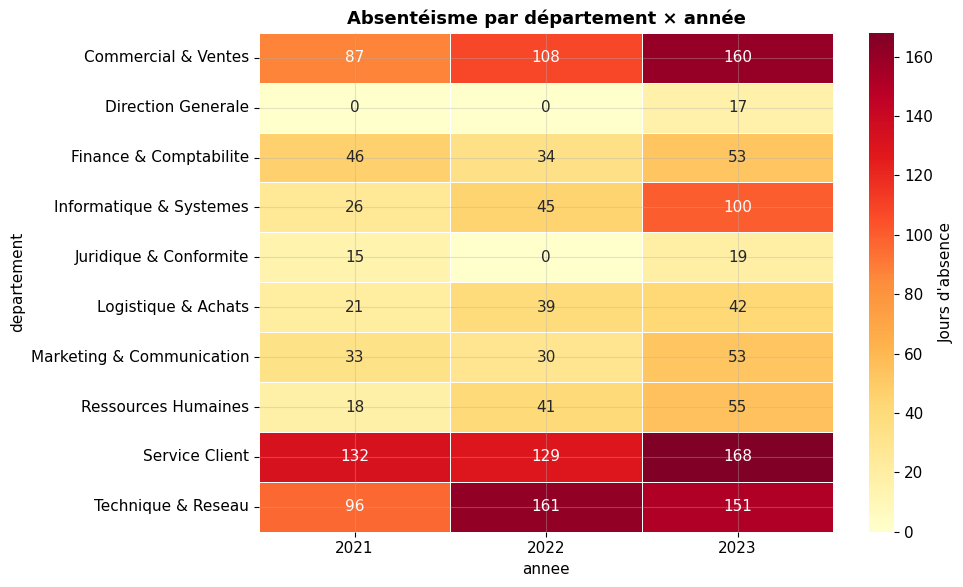

✅ Sauvegardé : ./outputs/heatmap_absenteisme.png


In [63]:
# Pivot pandas → heatmap saisonnalité absences
pivot_abs = df_abs_raw.pivot_table(
    index='departement', columns='annee', values='total_jours'
).fillna(0).astype(int)

# Variation 2022→2023
pivot_abs['delta_2022_2023'] = pivot_abs[2023] - pivot_abs[2022]

print('=== Jours d\'absence par département et par année ===')
print(pivot_abs.sort_values('delta_2022_2023', ascending=False).to_string())

# Visualisation heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot_abs[[2021, 2022, 2023]], annot=True, fmt='d',
    cmap='YlOrRd', linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Jours d\'absence'}
)
ax.set_title('Absentéisme par département × année', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}heatmap_absenteisme.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Sauvegardé : {SAVE_PATH}heatmap_absenteisme.png')

In [51]:
%%sql df_abs_injust <<
-- Taux d'absentéisme injustifié par département
SELECT
    d.nom                                                        AS departement,
    COUNT(CASE WHEN a.justifiee = false THEN 1 END)              AS nb_absences_injust,
    SUM(CASE WHEN a.justifiee = false THEN a.nb_jours ELSE 0 END) AS jours_injustifies,
    SUM(a.nb_jours)                                              AS total_jours_absences,
    ROUND(
        SUM(CASE WHEN a.justifiee = false THEN a.nb_jours ELSE 0 END) * 100.0
        / NULLIF(SUM(a.nb_jours), 0)
    , 1)                                                         AS pct_injustifiees,
    RANK() OVER (
        ORDER BY SUM(CASE WHEN a.justifiee = false
                          THEN a.nb_jours ELSE 0 END) DESC
    )                                                            AS rang
FROM vw_absences_valides a
JOIN departements d ON a.departement_id = d.departement_id
GROUP BY d.departement_id, d.nom
ORDER BY rang

In [64]:
df_abs_injust

,departement,nb_absences_injust,jours_injustifies,total_jours_absences,pct_injustifiees,rang
0,Technique & Reseau,22,106.00,507.00,20.90,1
1,Service Client,27,95.00,552.00,17.20,2
2,Commercial & Ventes,18,68.00,456.00,14.90,3
3,Finance & Comptabilite,14,43.00,170.00,25.30,4
4,Ressources Humaines,8,39.00,127.00,30.70,5
5,Informatique & Systemes,8,21.00,186.00,11.30,6
6,Marketing & Communication,4,16.00,137.00,11.70,7
7,Logistique & Achats,6,11.00,123.00,8.90,8
8,Direction Generale,2,7.00,21.00,33.30,9
9,Juridique & Conformite,2,4.00,64.00,6.30,10


> **INTERPRÉTATION — Absentéisme 2023 :**
>
> | Département | 2021 | 2022 | 2023 | Delta |
> |---|---|---|---|---|
> | Commercial & Ventes | 87j | 108j | **160j** | **+52j** |
> | Service Client | 132j | 129j | **168j** | **+39j** |
> | Technique & Réseau | 96j | 161j | **151j** | **-10j** |
>
> **MÉTIER — Service Client est en situation critique :** 168 jours d'absence en 2023 pour 130 employés. Ce département cumule sous-effectif (-14), absences en hausse +53% et turnover à 10.8% — le signal le plus fort de tension opérationnelle.

---
## Étape 6 — Coût recrutement par canal

### MÉTHODE — Coût par embauche réelle

Le `cout_recrutement` est le coût du processus. Le vrai indicateur de performance est le **coût par embauche réelle** = coût total du canal / nombre d'embauches réussies. Un canal bon marché avec un faible taux de conversion peut coûter plus cher par embauche qu'un canal coûteux mais efficace.

In [65]:
%%sql 
-- Performance des canaux de recrutement
SELECT
    canal,
    COUNT(*)                                                         AS nb_recrutements,
    SUM(CAST(embauche AS INTEGER))                                   AS nb_embauches,
    ROUND(SUM(CAST(embauche AS DOUBLE)) * 100.0 / COUNT(*), 1)      AS taux_embauche_pct,
    ROUND(AVG(CAST(duree_jours AS DOUBLE)), 0)                       AS duree_moy_jours,
    ROUND(AVG(CAST(cout_recrutement AS DOUBLE)), 0)                  AS cout_moyen_process,
    ROUND(
        SUM(CAST(cout_recrutement AS DOUBLE))
        / NULLIF(SUM(CAST(embauche AS INTEGER)), 0)
    , 0)                                                             AS cout_par_embauche,
    RANK() OVER (
        ORDER BY SUM(CAST(cout_recrutement AS DOUBLE))
                 / NULLIF(SUM(CAST(embauche AS INTEGER)), 0) ASC
    )                                                                AS rang_efficacite
FROM recrutements
GROUP BY canal
ORDER BY rang_efficacite

,canal,nb_recrutements,nb_embauches,taux_embauche_pct,duree_moy_jours,cout_moyen_process,cout_par_embauche,rang_efficacite
0,Cabinet,60,47.00,78.30,41.00,1342255.00,1713517.00,1
1,Referencement,66,45.00,68.20,44.00,1276897.00,1872783.00,2
2,LinkedIn,117,76.00,65.00,43.00,1425962.00,2195231.00,3
3,Cooptation,32,21.00,65.60,50.00,1471856.00,2242828.00,4
4,Jobboard,75,41.00,54.70,43.00,1323127.00,2420353.00,5


> **INTERPRÉTATION — Canaux de recrutement :**
>
> | Canal | Taux emb. | Durée moy. | Coût/emb. | Rang |
> |---|---|---|---|---|
> | Cabinet | **78.3%** | 41j | 1 713 517 FCFA | **1** |
> | Référencement | 68.2% | 44j | 1 872 783 FCFA | 2 |
> | LinkedIn | 65.0% | 43j | 2 195 231 FCFA | 3 |
> | Jobboard | 54.7% | 43j | **2 420 353 FCFA** | 5 |
>
> **MÉTIER — Contre-intuitif :** le Cabinet est le canal le moins coûteux par embauche réelle, malgré son coût de processus moyen. Son taux de conversion exceptionnel (78.3%) compense largement. **Recommandation :** réduire les offres Jobboard et renforcer le budget Cabinet et Référencement.

---
## Rapport département — fonction Python (remplace la procédure stockée)

### MÉTHODE — Pourquoi une fonction Python ?

| Avantage | Détail |
|---|---|
| **Réutilisabilité** | `rapport_departement('DEP02')` — 1 ligne au lieu de 40 |
| **Flexibilité** | Peut enchaîner avec pandas et matplotlib |
| **Portabilité** | Fonctionne dans Colab et en local sans SQL Server |

> **DuckDB :** `DATE_DIFF('year', date_embauche, CURRENT_DATE)` remplace `DATEDIFF(YEAR, date_embauche, GETDATE())`.

In [66]:
def rapport_departement(dept_id: str, annee: int = 2023):
    """Génère le rapport RH complet pour un département et une année.
    Équivalent de sp_rapport_rh_departement en SQL Server.
    """
    # KPIs annuels
    df_kpis = conn.execute(f"""
        SELECT
            d.nom                                                           AS departement,
            {annee}                                                         AS annee,
            COUNT(CASE WHEN e.statut = 'Actif' THEN 1 END)                 AS effectif_actif,
            COUNT(CASE WHEN YEAR(e.date_depart) = {annee} THEN 1 END)      AS departs_annee,
            ROUND(COUNT(CASE WHEN YEAR(e.date_depart) = {annee} THEN 1 END)
                  * 100.0 / NULLIF(COUNT(*), 0), 1)                        AS taux_turnover_pct,
            ROUND(AVG(CASE WHEN e.statut = 'Actif'
                THEN DATE_DIFF('year', e.date_embauche, CURRENT_DATE) END), 1) AS anciennete_moy
        FROM employes e
        JOIN departements d ON e.departement_id = d.departement_id
        WHERE e.departement_id = '{dept_id}'
        GROUP BY d.nom
    """).df()

    # Masse salariale de l'année
    df_sal = conn.execute(f"""
        SELECT
            ROUND(SUM(salaire_brut + prime), 0)  AS masse_salariale_annee,
            ROUND(AVG(salaire_brut), 0)          AS sal_brut_moyen,
            ROUND(AVG(salaire_net), 0)           AS sal_net_moyen
        FROM vw_salaires_valides
        WHERE departement_id = '{dept_id}'
          AND annee = {annee}
    """).df()

    # Absentéisme de l'année
    df_abs = conn.execute(f"""
        SELECT
            SUM(nb_jours)                                          AS total_jours_absence,
            SUM(CASE WHEN justifiee = false THEN nb_jours ELSE 0 END) AS jours_injustifies,
            ROUND(SUM(CASE WHEN justifiee = false THEN nb_jours ELSE 0 END)
                  * 100.0 / NULLIF(SUM(nb_jours), 0), 1)          AS pct_injustifiees
        FROM vw_absences_valides
        WHERE departement_id = '{dept_id}'
          AND YEAR(date_debut) = {annee}
    """).df()

    # Note de performance
    df_perf = conn.execute(f"""
        SELECT
            ROUND(AVG(note_globale), 2) AS note_perf_moy,
            COUNT(*)                   AS nb_evalue
        FROM evaluations
        WHERE departement_id = '{dept_id}'
          AND annee = {annee}
    """).df()

    nom_dept = df_kpis.iloc[0]['departement'] if len(df_kpis) else dept_id
    print(f"{'='*50}")
    print(f"  RAPPORT RH : {nom_dept}")
    print(f"  ANNÉE      : {annee}")
    print(f"{'='*50}")
    print('\n--- Effectif ---')
    display(df_kpis)
    print('\n--- Masse salariale ---')
    display(df_sal)
    print('\n--- Absentéisme ---')
    display(df_abs)
    print('\n--- Performance ---')
    display(df_perf)

# Test sur Technique & Réseau (DEP02) — 2023
rapport_departement('DEP02', 2023)

  RAPPORT RH : Commercial & Ventes
  ANNÉE      : 2023

--- Effectif ---


,departement,annee,effectif_actif,departs_annee,taux_turnover_pct,anciennete_moy
0,Commercial & Ventes,2023,83,3,3.20,7.10



--- Masse salariale ---


,masse_salariale_annee,sal_brut_moyen,sal_net_moyen
0,1016234607.00,953393.00,878902.00



--- Absentéisme ---


,total_jours_absence,jours_injustifies,pct_injustifiees
0,160.00,19.00,11.90



--- Performance ---


,note_perf_moy,nb_evalue
0,3.77,83


> Appliquer `rapport_departement()` sur tous les départements à risque identifiés :
> - `rapport_departement('DEP06')` → Marketing & Communication (turnover 23.3%)
> - `rapport_departement('DEP01')` → Service Client (absences +39j en 2023)
> - `rapport_departement('DEP05')` → Finance & Comptabilité (turnover +8.6% en 2023)

---
## Export des datasets analytiques pour Power BI

In [67]:
# Export des datasets produits pour Power BI
df_ms_annuelle.to_csv(f'{SAVE_PATH}telcomci_masse_salariale.csv', index=False)
df_turnover.to_csv(f'{SAVE_PATH}telcomci_turnover.csv', index=False)
df_perf_detail.to_csv(f'{SAVE_PATH}telcomci_performance.csv', index=False)
df_alerte_rh.to_csv(f'{SAVE_PATH}telcomci_alerte_rh.csv', index=False)
df_recru.to_csv(f'{SAVE_PATH}telcomci_recrutement.csv', index=False)

print('Fichiers exportés ✅')
print('  telcomci_masse_salariale.csv  → évolution masse salariale')
print('  telcomci_turnover.csv         → taux de turnover')
print('  telcomci_performance.csv      → matrice performance × salaire')
print('  telcomci_alerte_rh.csv        → employés sous-payés performants')
print('  telcomci_recrutement.csv      → coût par canal')
print(f'\n📁 Localisation : {SAVE_PATH}')

Fichiers exportés ✅
  telcomci_masse_salariale.csv  → évolution masse salariale
  telcomci_turnover.csv         → taux de turnover
  telcomci_performance.csv      → matrice performance × salaire
  telcomci_alerte_rh.csv        → employés sous-payés performants
  telcomci_recrutement.csv      → coût par canal

📁 Localisation : ./outputs/


---
## Bilan du Notebook 2

### Réponses aux 5 questions DRH

| Question | Réponse |
|---|---|
| Évolution masse salariale | +16.8% (2021→2022) puis +15.0% (2022→2023) |
| Dept turnover le plus élevé | **Finance 8.6%** et **Marketing 6.7%** en 2023 |
| Employés sous-payés performants | **35 employés** (note moy 4.21, sal 622k FCFA) |
| Canal recrutement le plus efficace | **Cabinet** (taux 78.3%, coût/emb le plus bas) |
| Absentéisme en hausse 2023 | **Oui — Service Client +39j, Commercial +52j** |

### Patterns SQL maîtrisés

| Pattern | Utilisation |
|---|---|
| `CREATE OR REPLACE VIEW` | Vues de nettoyage non destructives |
| `LAG() OVER (PARTITION BY)` | Variation mensuelle masse salariale |
| `RANK() OVER (PARTITION BY)` | Classement dans un groupe |
| `NTILE(4) OVER` | Segmentation en quartiles salariaux |
| `PERCENT_RANK() OVER` | Rang relatif performance |
| `PERCENTILE_CONT(0.5)` | Calcul de la médiane |
| `pandas.pivot_table()` | Heatmap absentéisme (remplace PIVOT SQL Server) |
| Fonction Python | Rapport RH paramétré (remplace CREATE PROCEDURE) |
| `NULLIF(expr, 0)` | Protection division par zéro |
| `DATE_DIFF('year', d, CURRENT_DATE)` | Ancienneté (remplace DATEDIFF SQL Server) |

---

**DataProjectLab** — apprendre la data sur des cas concrets, structurés et orientés métier.